**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Samuel Enrique Garza Montemayor
*   MATRÍCULA: A00829926


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [207]:
# Importa las librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?






In [208]:
weather_df = pd.read_csv('cleaned_weather.csv')

In [209]:
weather_df_01.shape # Dimensionalidad del df

(52696, 15)

In [210]:
weather_df.info() #Nombres de columnas 

<class 'pandas.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  52696 non-null  str    
 1   p          52696 non-null  float64
 2   T          52696 non-null  float64
 3   Tpot       52696 non-null  float64
 4   rh         52696 non-null  float64
 5   VPact      52696 non-null  float64
 6   sh         52696 non-null  float64
 7   H2OC       52696 non-null  float64
 8   rho        52696 non-null  float64
 9   wv         52696 non-null  float64
 10  wd         52696 non-null  float64
 11  rain       52696 non-null  float64
 12  raining    52696 non-null  int64  
dtypes: float64(11), int64(1), str(1)
memory usage: 5.2 MB


In [211]:
weather_df_ = ( 
    weather_df
            .rename(columns = {
                               'timestamp': 'medicion', 
                               'p':'presion_atmosferica', 
                               'T':'temperatura_celsius', 
                               'Tpot':'temperatura_kelvin', 
                               'rh': 'humedad_relativa', 
                               'VPact': 'presion_vapor', 
                               'sh':'humedad_especifica', 
                               'H2OC': 'concentracion_vapor', 
                               'rho':'densidad_aire', 
                               'wv':'velocidad_viento', 
                               'wd':'direccion_viento', 
                               'rain': 'precipitacion_total', 
                               'raining':'duracion_lluvia'
                               }
                    )
) # renombre de columnas

In [212]:
weather_df_.head() #primeros 5 registros

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,01/01/20 0:10,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,01/01/20 0:20,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,01/01/20 0:30,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0
3,01/01/20 0:40,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0
4,01/01/20 0:50,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0


In [213]:
weather_df_.tail() #ultimos 5 registros

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
52691,31/12/20 23:20,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0
52692,31/12/20 23:30,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0
52693,31/12/20 23:40,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0
52694,31/12/20 23:50,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0
52695,01/01/21 0:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0


In [214]:
weather_df_.isna().sum() #No hay valores faltantes en el df

medicion               0
presion_atmosferica    0
temperatura_celsius    0
temperatura_kelvin     0
humedad_relativa       0
presion_vapor          0
humedad_especifica     0
concentracion_vapor    0
densidad_aire          0
velocidad_viento       0
direccion_viento       0
precipitacion_total    0
duracion_lluvia        0
dtype: int64

No hay valores faltantes (NULL) en ninguna columna

2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [215]:
weather_df_.dtypes 

medicion                   str
presion_atmosferica    float64
temperatura_celsius    float64
temperatura_kelvin     float64
humedad_relativa       float64
presion_vapor          float64
humedad_especifica     float64
concentracion_vapor    float64
densidad_aire          float64
velocidad_viento       float64
direccion_viento       float64
precipitacion_total    float64
duracion_lluvia          int64
dtype: object

Aqui podemos ver los tipos de dato por cada columnas. Todas las columnas son float, excepto 'medicion', la cual es un string, y 'duracion_lluvia', la cual es entero

In [216]:
weather_df_01 = (weather_df_
                    .assign(
                            medicion = lambda df_: pd.to_datetime(df_.medicion, format = "%d/%m/%y %H:%M"), 
                            fecha=lambda df_: df_.medicion.dt.date,
                            hora=lambda df_: df_.medicion.dt.time
                            )
) #cambiamos el formarto de medicion a día/mes/año/hora/minuto. Y agregamos la columna de fecha y hora

In [217]:
weather_df_01[['medicion']].dtypes # comprobacion de que si se cambio a formato de fecha

medicion    datetime64[us]
dtype: object

La columna medicion ya está en formato de fecha (día/mes/año/hora/minuto)

Se crearon las columnas de fecha y hora

In [218]:
weather_df_01[['medicion', 'fecha', 'hora']] # comprobacion que si se crearon las dos columnas de manera correcta

,medicion,fecha,hora
0,2020-01-01 00:10:00,2020-01-01,00:10:00
1,2020-01-01 00:20:00,2020-01-01,00:20:00
2,2020-01-01 00:30:00,2020-01-01,00:30:00
3,2020-01-01 00:40:00,2020-01-01,00:40:00
4,2020-01-01 00:50:00,2020-01-01,00:50:00
...,...,...,...
52691,2020-12-31 23:20:00,2020-12-31,23:20:00
52692,2020-12-31 23:30:00,2020-12-31,23:30:00
52693,2020-12-31 23:40:00,2020-12-31,23:40:00
52694,2020-12-31 23:50:00,2020-12-31,23:50:00


3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [219]:
weather_df_01.nunique() # cantidad de valores únicos de cada columna 

medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
fecha                    367
hora                     144
dtype: int64

In [220]:
weather_df_01['medicion'][weather_df_01['medicion'].duplicated()] # encontrar la fecha que se encuentra duplicada

19044   2020-05-12 06:00:00
Name: medicion, dtype: datetime64[us]

La fecha del 12 de Mayo es la que se tiene Duplicado

In [221]:
weather_df_01[weather_df_01['medicion'].duplicated(keep=False)] 

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
19043,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00
19044,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00


Toda la fila se encuentra duplicada

In [222]:
weather_df_02 = weather_df_01.drop_duplicates() # eliminar uno de los registros duplicados 

In [223]:
weather_df_02[weather_df_02['medicion'].duplicated(keep=False)] # Validación que ya no tenemos filas duplicadas

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora


4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [224]:
weather_df_01.nunique()  

medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
fecha                    367
hora                     144
dtype: int64

Se tienen 144 mediciones diarias, dado que se realiza una medición cada 10 minutos, al registrar 6 observaciones por horar, el total para las 24h del día es de 144 registtos (24 * 6 = 144)

In [225]:
(weather_df_01
            .groupby(by = 'fecha')
            .agg(horas = ('hora', 'nunique'))
            .query('horas != 144')
)

,horas
fecha,
2020-01-01,143
2020-05-29,135
2021-01-01,1


Aqui encontramos que el 1 de enero de 2020 esta incompleto, le falto 1 medición 

Tambien el día 29 de mayo de 2020 le hicieron falta 9 mediciones

In [226]:
weather_df_02 = (weather_df_01
    .query('medicion >= "2020-01-01" and medicion < "2021-01-01"')
    .drop(columns = 'medicion')
)

weather_df_02.fecha.agg(['min', 'max']) #eliminamos el registro de 2021 y lo comprobamos con un min y max.


min    2020-01-01
max    2020-12-31
Name: fecha, dtype: object

In [227]:
weather_df_02.columns # comprobamos que se elimino la columna de medicion 

Index(['presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin',
       'humedad_relativa', 'presion_vapor', 'humedad_especifica',
       'concentracion_vapor', 'densidad_aire', 'velocidad_viento',
       'direccion_viento', 'precipitacion_total', 'duracion_lluvia', 'fecha',
       'hora'],
      dtype='str')

5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [228]:
indicadores_diarios = (weather_df_02
                                .groupby('fecha')
                                .max(numeric_only = True)
                                .reset_index()
)

In [229]:
indicadores_diarios.precipitacion_total.max()

np.float64(11.2)

In [230]:
( 
    indicadores_diarios
               [['fecha', 'precipitacion_total']]
               .sort_values(by = 'precipitacion_total', ascending = False)
               .head(1)
)

,fecha,precipitacion_total
167,2020-06-16,11.2


La precipitación máxima fue de 11.2 y ocurrió el día 16 de Junio de 2026

In [231]:
( 
    indicadores_diarios
               [['fecha', 'velocidad_viento']]
               .sort_values(by = 'velocidad_viento', ascending = False)
               .head(3)

               # los 3 días con la máxima cantidad de viento fue el: 
               # 10 de febrero de 2020
               # 16 de febrero de 2020
               # 9 de febrero de 2020
)

,fecha,velocidad_viento
40,2020-02-10,13.77
46,2020-02-16,13.00
39,2020-02-09,12.52


Los 3 días con la máxima cantidad de viento fueron el: 

               10 de febrero de 2020

               16 de febrero de 2020

               9 de febrero de 2020

In [232]:
( 
    indicadores_diarios
                .query('humedad_relativa >= 90')
                .query('temperatura_celsius >= 30')
                .fecha.nunique()
                #5 días fue que se revasó al mismo tiempo 90% de humedad relativa y 30 grados celsius
)

5

5 días fue que se revasó al mismo tiempo 90% de humedad relativa y 30 grados celsius

6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [233]:
indicadores_diarios.concentracion_vapor.describe() 

count    366.000000
mean      11.539180
std        4.573267
min        3.290000
25%        7.742500
50%       10.735000
75%       14.685000
max       24.530000
Name: concentracion_vapor, dtype: float64

La desviación estandar es de 4.57, respecto a una promedio de 11.54 significa que la concentración de vapor cambia de manera significativa a lo largo de los datos. 

In [234]:
indicadores_diarios.presion_atmosferica.describe()

count     366.000000
mean      992.977842
std         8.543447
min       959.900000
25%       988.015000
50%       993.300000
75%       998.432500
max      1020.070000
Name: presion_atmosferica, dtype: float64

La mediana de la presión atmosférica es de 993,3, y su media es de 992.9, lo que nos indica que no existen muchos datos atípcios. De hecho, viendo igual la desviación estándar de 8.5 nos muestra una dispersión moderada y estable alrededor del centro

<Axes: title={'center': 'Distribución Presión Atmosférica'}, ylabel='Frequency'>

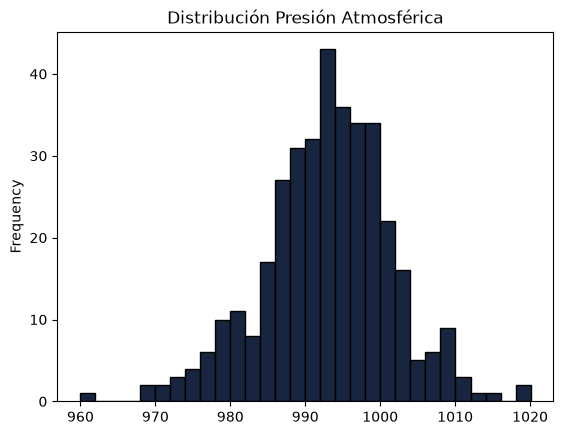

In [235]:
indicadores_diarios.presion_atmosferica.plot(kind = 'hist', color = '#18253e', bins = 30, edgecolor = 'black', title = 'Distribución Presión Atmosférica') 
# comprobamos que la distribución se asemeja a una curva normal

In [237]:
indicadores_diarios.duracion_lluvia.describe()

count    366.000000
mean     240.382514
std      273.840002
min        0.000000
25%        0.000000
50%        0.000000
75%      600.000000
max      600.000000
Name: duracion_lluvia, dtype: float64

El 3er cuartil de la duración de la lluvia es 600.

Interpretación: El 75% de los días  tienen una duración de lluvia <=  600

7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

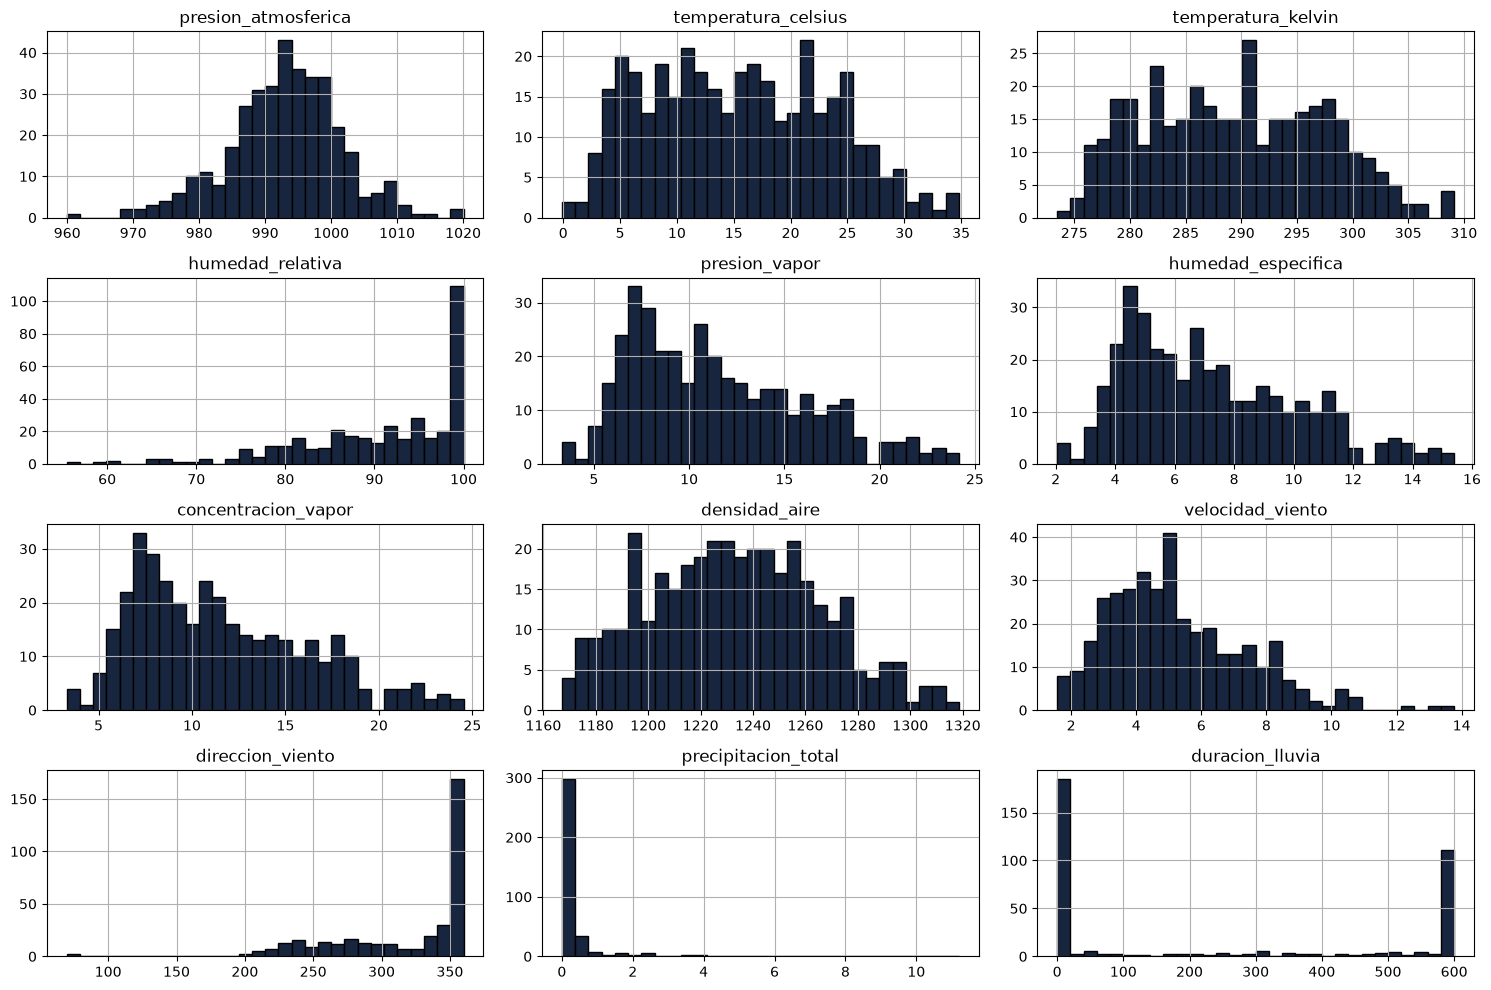

In [167]:
indicadores_diarios.hist(figsize = (15,10), bins = 30, edgecolor = 'black', color = '#18253e' )
plt.tight_layout()
plt.show()

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [186]:
indicadores_mensuales = (
    indicadores_diarios

    .assign(fecha = lambda df_: pd.to_datetime(df_.fecha ))
            .assign(Mes = lambda df_: df_.fecha.dt.month)

    .groupby(by = 'Mes')
    .agg(humedad_relativa_promedio= ('humedad_relativa', 'mean'),
        temperatura_celsius_promedio = ('temperatura_celsius', 'mean'), 
        velocidad_viento_promedio = ('velocidad_viento', 'mean'))
        
)

In [187]:
indicadores_mensuales #indicadores promedio por mes 

,humedad_relativa_promedio,temperatura_celsius_promedio,velocidad_viento_promedio
Mes,,,
1,89.776129,6.821290,5.031935
2,85.719655,8.962414,7.489655
3,85.372903,9.683871,6.421290
4,80.938667,16.879667,4.997000
5,87.464839,17.135484,4.865806
6,94.256000,22.212000,5.296667
7,85.959355,24.336129,4.830323
8,92.002581,26.097742,5.040323
9,97.570000,21.571667,4.153333


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [192]:
indicadores_mensuales = (
    indicadores_diarios
    .assign(fecha=lambda df_: pd.to_datetime(df_.fecha))
    .assign(Mes=lambda df_: df_.fecha.dt.month)
    .pivot_table(
        index='Mes',
        values=['humedad_relativa', 'temperatura_celsius', 'velocidad_viento'],
        aggfunc='mean'
    )
    
    .assign(indice_calor=lambda df_: (df_.temperatura_celsius + 0.33 * df_.humedad_relativa - 0.7 * df_.velocidad_viento- 4))
)

In [193]:
indicadores_mensuales

,humedad_relativa,temperatura_celsius,velocidad_viento,indice_calor
Mes,,,,
1,89.776129,6.821290,5.031935,28.925058
2,85.719655,8.962414,7.489655,28.007141
3,85.372903,9.683871,6.421290,29.362026
4,80.938667,16.879667,4.997000,36.091527
5,87.464839,17.135484,4.865806,38.592816
6,94.256000,22.212000,5.296667,45.608813
7,85.959355,24.336129,4.830323,45.321490
8,92.002581,26.097742,5.040323,48.930368
9,97.570000,21.571667,4.153333,46.862433


10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [ ]:
df_melt = (
    indicadores_mensuales
    .reset_index()
    .melt(
        id_vars=['Mes'],
        var_name='indicador',
        value_name='valor'
    )
)

df_melt.head(10) # convertimos el datafrane a lo largo 

,Mes,indicador,valor
0,1,humedad_relativa,89.776129
1,2,humedad_relativa,85.719655
2,3,humedad_relativa,85.372903
3,4,humedad_relativa,80.938667
4,5,humedad_relativa,87.464839
5,6,humedad_relativa,94.256000
6,7,humedad_relativa,85.959355
7,8,humedad_relativa,92.002581
8,9,humedad_relativa,97.570000
9,10,humedad_relativa,96.950645


In [200]:
df_stack = indicadores_mensuales.stack()

df_stack_flat = (
    df_stack
    .reset_index(name='valor')
    .rename(columns={'level_1': 'indicador'})
)

df_stack_flat.head(10)

,Mes,indicador,valor
0,1,humedad_relativa,89.776129
1,1,temperatura_celsius,6.821290
2,1,velocidad_viento,5.031935
3,1,indice_calor,28.925058
4,2,humedad_relativa,85.719655
5,2,temperatura_celsius,8.962414
6,2,velocidad_viento,7.489655
7,2,indice_calor,28.007141
8,3,humedad_relativa,85.372903
9,3,temperatura_celsius,9.683871


La función melt() nos devolvió un df organizado variable por variable. Va mostrando el valor de cada variable para todos los meses, y despues le continua con la siguiente variable para todos los meses. 

La función stack() nos apiló las columnas directamente sobre el índice original, es decir va mostrando por el Mes 1 (Enero) los valores de las 4 variables, después de pasa a Mes 2, Mes 3...

---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

Por ejemplo:

*   Google. (2026). *Gemini (basado en Flash)* [Modelo de lenguaje grande], utilizado para correción de errores y generación del código de histogramas y stack. https://gemini.google.com/app?hl=es-MX

---